In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import  mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor

In [4]:
region = pd.read_csv('region.csv')

In [5]:
df = pd.read_csv('realty_18_21.csv')

In [6]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['year'].unique()

array([2018, 2019, 2020, 2021], dtype=int32)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 11 columns):
 #   Column         Dtype         
---  ------         -----         
 0   price          int64         
 1   date           datetime64[ns]
 2   region         int64         
 3   building_type  int64         
 4   level          int64         
 5   levels         int64         
 6   rooms          int64         
 7   area           float64       
 8   kitchen_area   float64       
 9   object_type    int64         
 10  year           int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(7)
memory usage: 438.8 MB


In [8]:
region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   code      83 non-null     object
 1   reg_name  83 non-null     object
dtypes: object(2)
memory usage: 1.4+ KB


In [9]:
region[region['code']=='7873, 6937']

,code,reg_name
36,"7873, 6937",Республика Крым


In [10]:
region.loc[region['code'] == '7873, 6937', 'code'] = '82'

In [11]:
region[region['code']=='82']

,code,reg_name
36,82,Республика Крым


In [12]:
region['code'] = region['code'].astype(int)

In [13]:
df = df.merge(region, left_on='region', right_on='code', how='left')
df

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,year,code,reg_name
0,6050000,2018-02-19,2661,1,8,10,3,82.6,10.8,1,2018,2661.0,Санкт-Петербург
1,8650000,2018-02-27,81,3,5,24,2,69.1,12.0,1,2018,81.0,Московская область
2,4000000,2018-02-28,2871,1,5,9,3,66.0,10.0,1,2018,2871.0,Нижегородская область
3,1850000,2018-03-01,2843,4,12,16,2,38.0,5.0,11,2018,2843.0,Краснодарский край
4,5450000,2018-03-01,81,3,13,14,2,60.0,10.0,1,2018,81.0,Московская область
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5477001,19739760,2021-05-01,3,1,8,17,4,93.2,13.8,11,2021,3.0,Москва
5477002,12503160,2021-05-01,3,2,17,32,2,45.9,6.6,11,2021,3.0,Москва
5477003,8800000,2021-05-01,2871,2,4,17,3,86.5,11.8,1,2021,2871.0,Нижегородская область
5477004,11831910,2021-05-01,3,1,8,33,2,52.1,18.9,11,2021,3.0,Москва


In [14]:
df.duplicated().sum()

235655

In [15]:
df = df.drop_duplicates()

In [16]:
df[df['kitchen_area'].isnull()]

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,year,code,reg_name
19,1650000,2018-03-16,2843,3,5,5,2,51.00,NaN,1,2018,2843.0,Краснодарский край
42,4400000,2018-04-14,81,3,11,14,2,54.00,NaN,1,2018,81.0,Московская область
78,2980000,2018-06-04,4417,1,7,9,2,52.00,NaN,1,2018,4417.0,Республика Коми
114,2900000,2018-07-12,81,3,2,9,1,37.50,NaN,1,2018,81.0,Московская область
136,5800000,2018-07-31,2661,2,6,14,1,47.10,NaN,1,2018,2661.0,Санкт-Петербург
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5476919,3247500,2021-05-01,6543,0,7,12,-1,43.30,NaN,11,2021,6543.0,Архангельская область
5476924,4250770,2021-05-01,6543,0,12,12,2,59.87,NaN,11,2021,6543.0,Архангельская область
5476979,23319120,2021-05-01,3,2,2,11,3,96.36,NaN,11,2021,3.0,Москва
5476982,13403880,2021-05-01,3,2,4,23,2,59.10,NaN,11,2021,3.0,Москва


In [17]:
df['kitchen_area'].isnull().sum()

252682

In [18]:
len(df[df['rooms']<0])

268040

In [19]:
df['price_m2'] = df['price'] / df['area']
df['log_price_m2'] = np.log1p(df['price_m2'])

/tmp/ipykernel_3439/3195032159.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_m2'] = df['price'] / df['area']
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_3439/3195032159.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_price_m2'] = np.log1p(df['price_m2'])


Датасет содержит объявления о недвижимости в РФ за 2018–2021 годы. В ходе предобработки было обнаружено 235 655 полных дубликатов, которые были удалены. Выявлены серьёзные проблемы с качеством данных: 252 682 пропуска в столбце kitchen_area, а также 268 040 записей с отрицательным числом комнат. Кроме того, обнаружены записи, в которых этаж квартиры превышает этажность дома, и случаи, где площадь кухни больше общей площади — все они были отфильтрованы как аномальные.

# Убираем выбросы

In [20]:
def remove_outliers(group):
    q01 = group['log_price_m2'].quantile(0.01)
    q99 = group['log_price_m2'].quantile(0.99)
    return group[(group['log_price_m2'] >= q01) & (group['log_price_m2'] <= q99)]

In [21]:
size = len(df)

<Axes: >

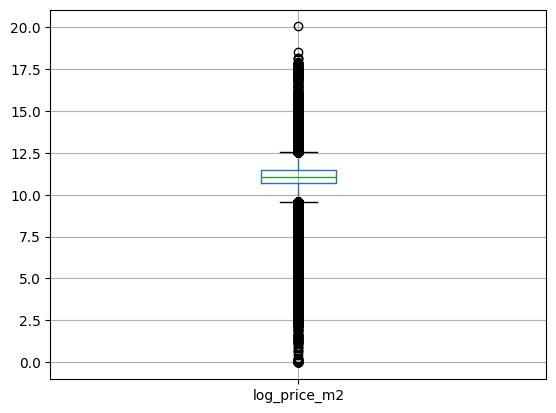

In [22]:
df.boxplot(column='log_price_m2')

In [23]:
df = df.groupby('region', group_keys=False).apply(remove_outliers)

/tmp/ipykernel_3439/3326263906.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('region', group_keys=False).apply(remove_outliers)


In [24]:
len(df) - size

-104884

Выбросы удалены по 1-му и 99-му перцентилям логарифма цены за м² в разрезе регионов (~104 884 записи).

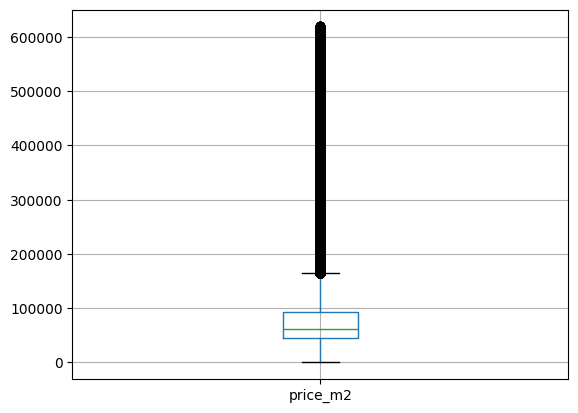

In [25]:
df.boxplot(column='price_m2')
plt.show()

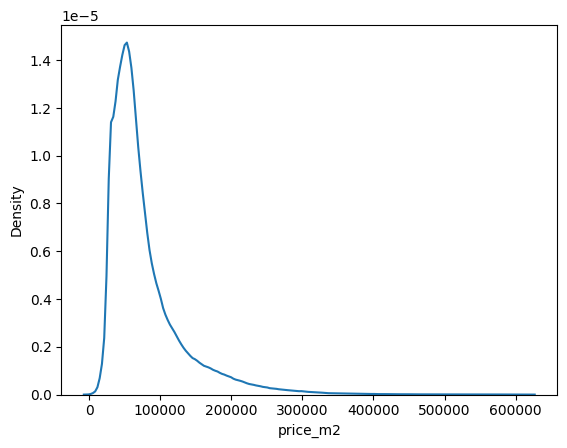

In [26]:
sns.kdeplot(df['price_m2'])
plt.show()

In [27]:
df['price_m2'].hist(bins=50)

<Axes: >

In [28]:
df['log_price_m2'].hist(bins=50)

<Axes: >

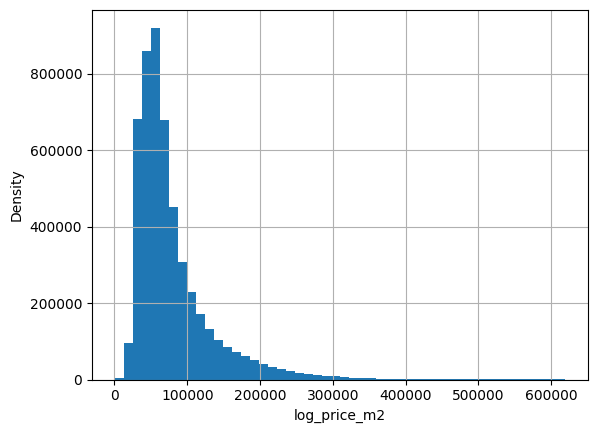

In [29]:
sns.kdeplot(df['log_price_m2'])
plt.show()

In [30]:
df.sort_values(ascending=False, by='price_m2').head(20)

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,year,code,reg_name,price_m2,log_price_m2
2728698,116180680,2019-10-10,3,2,12,13,3,187.6,52.7,11,2019,3.0,Москва,619300.000000,13.336347
4876167,70100000,2020-12-20,3,2,2,6,3,113.2,11.2,11,2020,3.0,Москва,619257.950530,13.336279
5390990,8050000,2021-04-24,3,3,2,5,-1,13.0,2.0,1,2021,3.0,Москва,619230.769231,13.336235
583728,216698000,2018-11-27,3,3,8,9,7,350.0,25.0,1,2018,3.0,Москва,619137.142857,13.336084
4722374,98122700,2020-11-17,3,2,5,6,3,158.5,20.0,11,2020,3.0,Москва,619070.662461,13.335976
4720506,6190000,2020-11-17,3,3,2,7,-1,10.0,2.0,1,2020,3.0,Москва,619000.000000,13.335862
493719,128705050,2018-11-15,3,2,8,18,4,208.0,16.0,1,2018,3.0,Москва,618774.278846,13.335497
4757784,99000000,2020-11-25,3,2,5,6,4,160.0,18.0,1,2020,3.0,Москва,618750.000000,13.335458
4969132,49500000,2021-01-28,3,3,16,18,2,80.0,15.0,1,2021,3.0,Москва,618750.000000,13.335458
4587517,49500000,2020-10-20,3,3,4,4,3,80.0,15.0,1,2020,3.0,Москва,618750.000000,13.335458


Распределение price_m2 имеет правую асимметрию; логарифмированная версия близка к нормальному распределению.

# Анализируем взаимосвязь, между отрицательными комнатами с нормальными данными

In [31]:
df[df['rooms'] < 0]['rooms'].value_counts()

rooms
-1    261494
-2       183
Name: count, dtype: int64

In [32]:
df_positive = df[df['rooms'] > 0]
df_negative = df[df['rooms'] < 0]

In [33]:
%%time
X = df_positive[['area', 'kitchen_area', 'price', 'level', 'levels', 'building_type']]
y = df_positive['rooms']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=1, n_jobs=-1)
model.fit(X_train, y_train)

CPU times: user 16min 46s, sys: 12.3 s, total: 16min 59s
Wall time: 1min 46s


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [34]:
accuracy_score(y_test, model.predict(X_test))

0.9055590086957592

In [35]:
X_negative = df_negative[['area', 'kitchen_area', 'price', 'level', 'levels', 'building_type']]
predicted_rooms = model.predict(X_negative)
actual_rooms_abs = df_negative['rooms'].abs()

In [36]:
comparison = pd.DataFrame({
    'abs': actual_rooms_abs.values,
    'predicted': predicted_rooms
})
comparison

,abs,predicted
0,1,1
1,1,1
2,1,1
3,1,2
4,1,2
...,...,...
261672,1,1
261673,1,2
261674,1,2
261675,1,1


In [37]:
(comparison['predicted'] == comparison['abs']).mean()

0.8473308697363544

In [38]:
df.loc[:, 'rooms'] = df['rooms'].abs()

Для проверки гипотезы о том, что отрицательное число комнат — это ошибка знака, была обучена модель RandomForestClassifier (accuracy 90.6% на тесте). Модель предсказала число комнат для записей с отрицательными значениями, и в 84.7% случаев предсказание совпало с абсолютным значением отрицательного числа. Это подтвердило гипотезу: отрицательные значения — ошибка ввода, и их можно заменить на модуль (abs).

# Прочее

In [39]:
df = df[df['kitchen_area'] < df['area']]

In [40]:
size = len(df[df['level'] > df['levels']]['levels'])

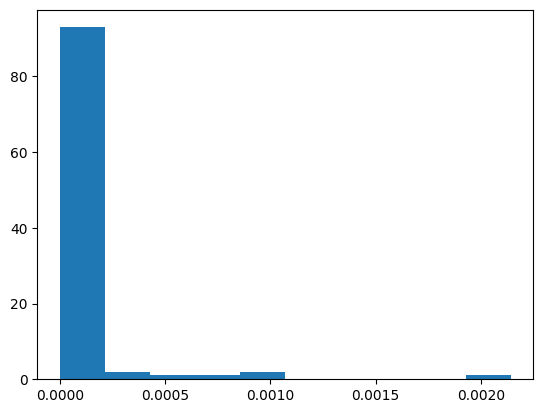

In [41]:
a = []
for i in range(100):
    a.append(st.ks_2samp(df[df['level'] > df['levels']]['levels'], df.sample(size)['level']).pvalue)

plt.hist(a)
plt.show()

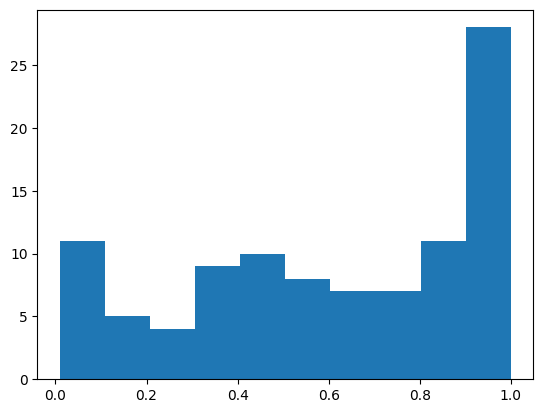

In [42]:
a = []
for i in range(100):
    a.append(st.ks_2samp(df.sample(size)['level'], df.sample(size)['level']).pvalue)

plt.hist(a)
plt.show()

In [43]:
df = df[(df['level'] <= df['levels'])]

# 5. Исследуйте рынок недвижимости в РФ за представленный период. Величина исследования - цена за м2. Обработайте аномалии.

In [44]:
df

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,year,code,reg_name,price_m2,log_price_m2
6,4704280,2018-03-04,3,2,1,25,1,31.7,6.0,11,2018,3.0,Москва,148400.000000,11.907673
20,8000000,2018-03-17,3,1,5,9,2,45.0,6.0,1,2018,3.0,Москва,177777.777778,12.088295
29,11500000,2018-04-03,3,1,14,16,3,64.9,8.0,1,2018,3.0,Москва,177195.685670,12.085016
34,10200000,2018-04-07,3,2,7,14,2,52.8,10.0,1,2018,3.0,Москва,193181.818182,12.171392
44,11500000,2018-04-18,3,1,14,17,1,42.0,12.0,1,2018,3.0,Москва,273809.523810,12.520192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5403169,2400000,2021-04-26,16705,4,2,5,1,32.0,9.1,1,2021,16705.0,Магаданская область,75000.000000,11.225257
5406403,6550000,2021-04-26,16705,4,4,5,3,69.0,9.5,1,2021,16705.0,Магаданская область,94927.536232,11.460880
606060,1400000,2018-11-29,61888,3,3,3,1,18.6,4.0,1,2018,61888.0,Ненецкий автономный округ,75268.817204,11.228834
619108,3500000,2018-11-30,61888,2,1,3,2,59.7,10.2,1,2018,61888.0,Ненецкий автономный округ,58626.465662,10.978959


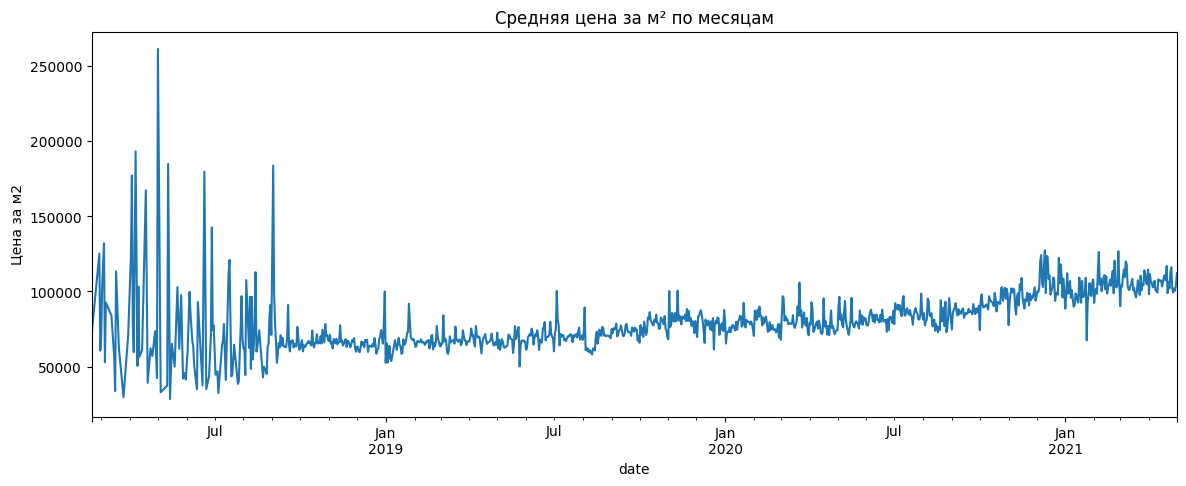

In [45]:
df['date'] = pd.to_datetime(df['date'])
df.groupby(df['date'].dt.to_period('d'))['price_m2'].mean().plot(figsize=(14, 5))
plt.title('Средняя цена за м² по месяцам')
plt.ylabel('Цена за м2')
plt.show()

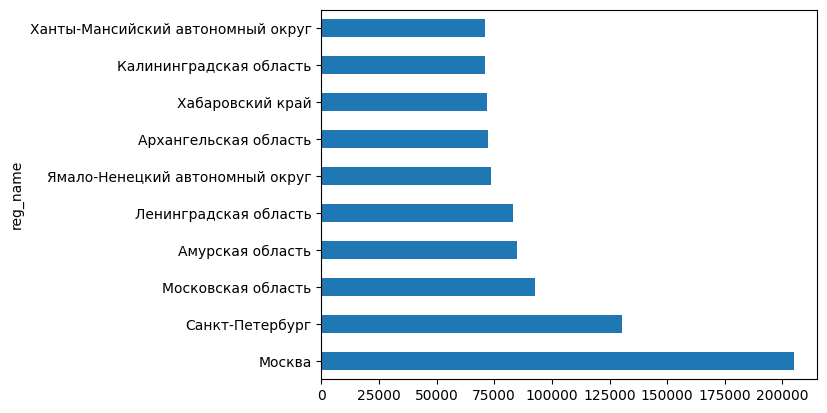

In [46]:
df.groupby('reg_name')['price_m2'].mean().sort_values(ascending=False).head(10).plot(kind='barh')
plt.show()

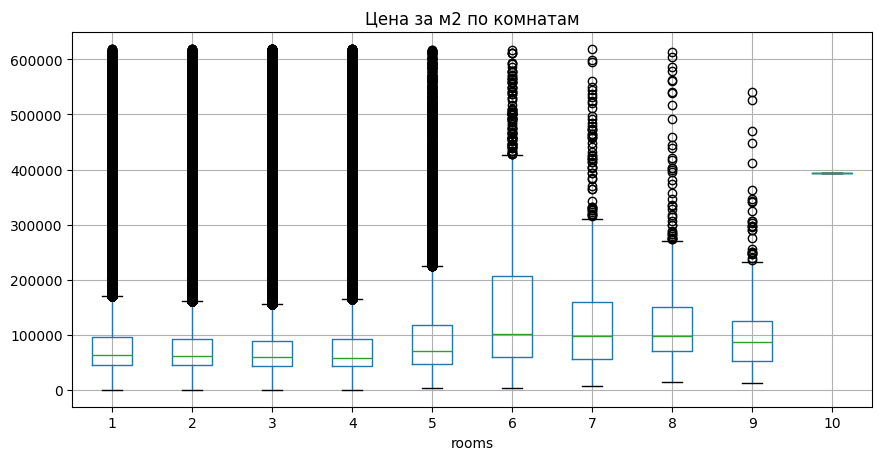

In [47]:
df.boxplot(column='price_m2', by='rooms', figsize=(10, 5))
plt.title('Цена за м2 по комнатам')
plt.suptitle('')
plt.show()

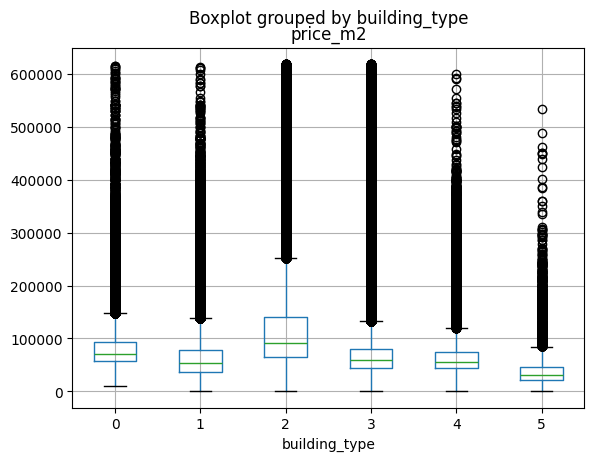

In [48]:
df.boxplot(column='price_m2', by='building_type')
plt.show()

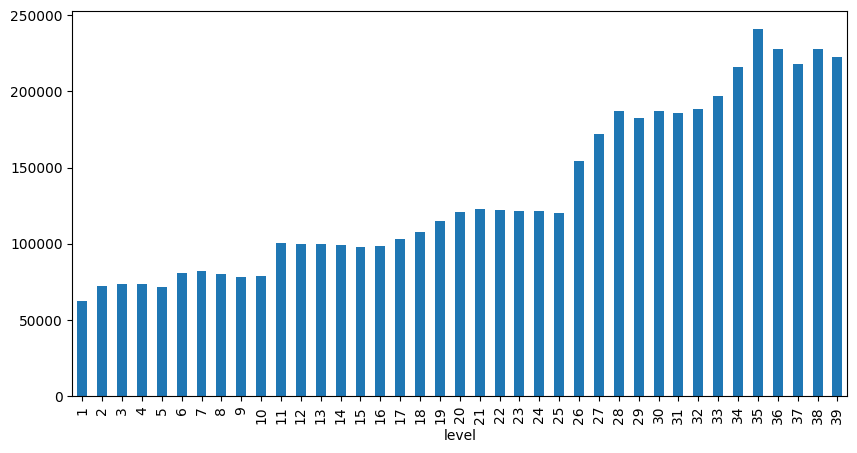

In [49]:
df.groupby('level')['price_m2'].mean().plot(kind='bar', figsize=(10, 5))
plt.show()

In [50]:
df[['price_m2', 'area', 'kitchen_area', 'rooms', 'level', 'levels']].corr()

,price_m2,area,kitchen_area,rooms,level,levels
price_m2,1.000000,0.088437,0.186143,0.001829,0.232529,0.346852
area,0.088437,1.000000,0.524598,0.733565,0.075824,0.081537
kitchen_area,0.186143,0.524598,1.000000,0.222668,0.200117,0.278647
rooms,0.001829,0.733565,0.222668,1.000000,-0.050626,-0.095869
level,0.232529,0.075824,0.200117,-0.050626,1.000000,0.662299
levels,0.346852,0.081537,0.278647,-0.095869,0.662299,1.000000


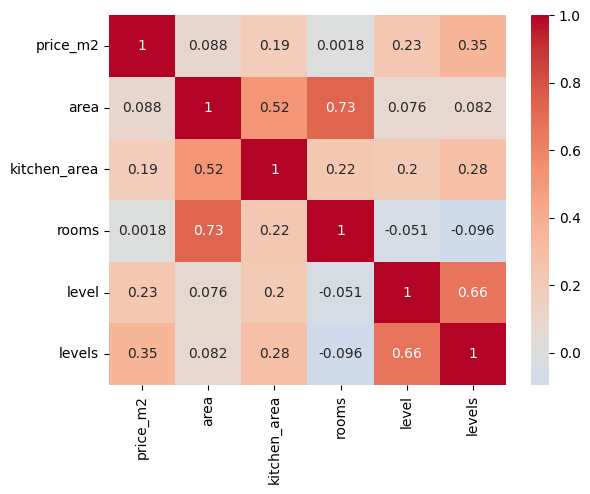

In [51]:
sns.heatmap(df[['price_m2', 'area', 'kitchen_area', 'rooms', 'level', 'levels']].corr(), annot=True, cmap='coolwarm', center=0)
plt.show()

### Анализ цен по годам

In [52]:
df['year'] = df['date'].dt.year

In [53]:
df.groupby(['reg_name', 'year'])['price_m2'].mean()

reg_name                         year
Алтайский край                   2018     42034.288162
                                 2019     42799.946424
                                 2020     45129.702162
                                 2021     52754.645818
Амурская область                 2018     56971.872189
                                             ...      
Ямало-Ненецкий автономный округ  2021    113416.826653
Ярославская область              2018     45349.694007
                                 2019     44782.011351
                                 2020     48295.645950
                                 2021     55628.517091
Name: price_m2, Length: 321, dtype: float64

In [54]:
price_by_year = df.groupby(['reg_name', 'year'])['price_m2'].mean().unstack()
price_by_year

year,2018,2019,2020,2021
reg_name,,,,
Алтайский край,42034.288162,42799.946424,45129.702162,52754.645818
Амурская область,56971.872189,63168.631751,81151.178571,103207.434546
Архангельская область,55594.112594,64282.636582,72577.340989,80306.676745
Астраханская область,38699.237297,36866.959124,46253.989548,54670.528774
Белгородская область,49462.549708,53013.352023,55035.006646,61449.819677
...,...,...,...,...
Челябинская область,36110.061053,37248.306406,38194.871373,43248.596800
Чеченская Республика,37362.799714,37773.110765,40718.308384,50836.504974
Чувашская Республика,40874.487440,42424.564982,45098.231092,51338.222662


In [55]:
for i in df['year'].unique():
    print(len(df[df['year']==i]))

765343
1934685
1670364
515957


In [56]:
price_by_year['growth'] = (price_by_year[2021] - price_by_year[2018]) / price_by_year[2018] * 100
price_by_year['growth']

reg_name
Алтайский край                     25.503840
Амурская область                   81.155069
Архангельская область              44.451765
Астраханская область               41.270300
Белгородская область               24.235043
                                     ...    
Челябинская область                19.768828
Чеченская Республика               36.061819
Чувашская Республика               25.599673
Ямало-Ненецкий автономный округ    86.373741
Ярославская область                22.665694
Name: growth, Length: 82, dtype: float64

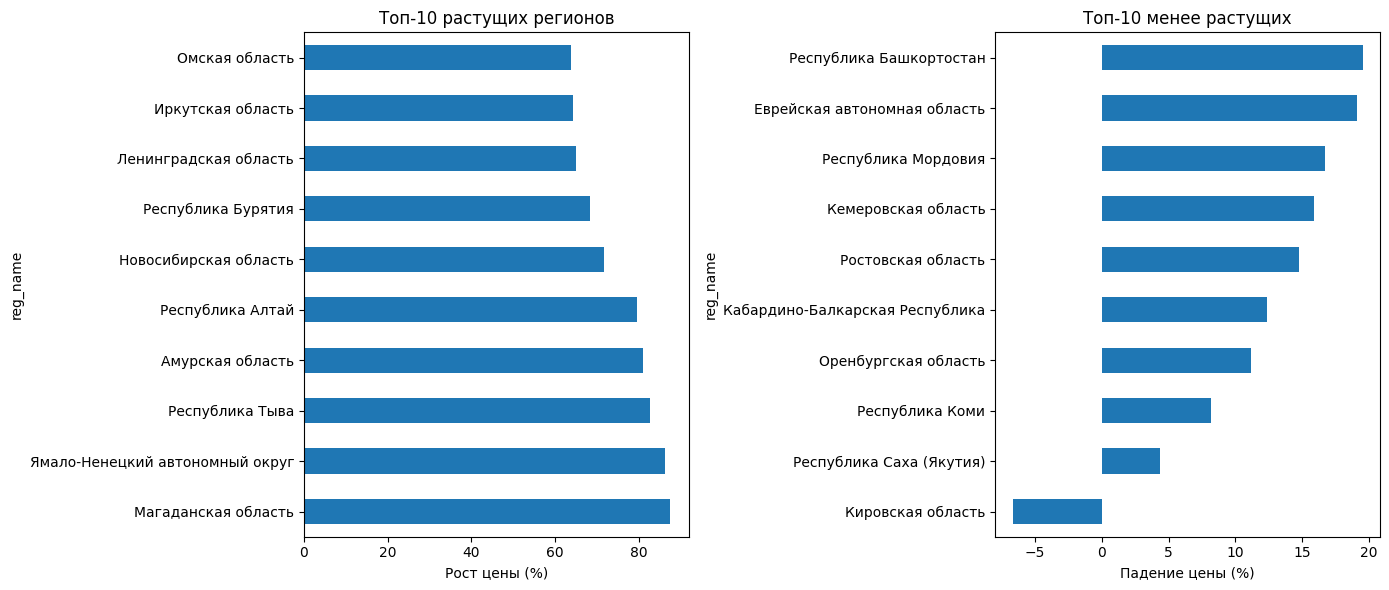

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

price_by_year['growth'].sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[0])
axes[0].set_title('Топ-10 растущих регионов')
axes[0].set_xlabel('Рост цены (%)')

price_by_year['growth'].sort_values().head(10).plot(kind='barh', ax=axes[1])
axes[1].set_title('Топ-10 менее растущих')
axes[1].set_xlabel('Падение цены (%)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3439/2357066589.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('area_bin')['price_m2'].mean().plot(kind='line', figsize=(12, 5))


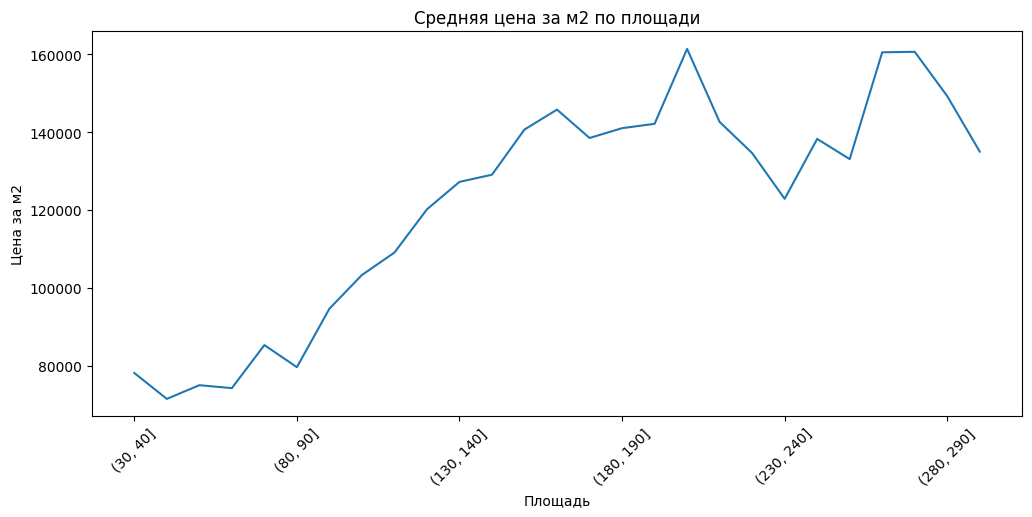

In [58]:
df['area_bin'] = pd.cut(df['area'], bins=list(range(30, 301, 10)))
df.groupby('area_bin')['price_m2'].mean().plot(kind='line', figsize=(12, 5))
plt.title('Средняя цена за м2 по площади')
plt.xlabel('Площадь')
plt.ylabel('Цена за м2')
plt.xticks(rotation=45)
plt.show()

In [59]:
price_trend = df.groupby(df['date'].dt.to_period('M'))['price_m2'].mean()
price_trend.index = price_trend.index.to_timestamp()
price_trend

date
2018-02-01     86343.836638
2018-03-01     81640.076158
2018-04-01     82833.470323
2018-05-01     73509.057942
2018-06-01     69517.306548
2018-07-01     59861.985501
2018-08-01     74110.832429
2018-09-01     68905.272021
2018-10-01     66985.772265
2018-11-01     66292.124412
2018-12-01     67990.339029
2019-01-01     66668.769501
2019-02-01     66730.179180
2019-03-01     67594.282116
2019-04-01     68281.625031
2019-05-01     67913.216928
2019-06-01     70573.859407
2019-07-01     71381.704542
2019-08-01     68372.748357
2019-09-01     73922.222481
2019-10-01     75951.897402
2019-11-01     81919.072577
2019-12-01     75949.977928
2020-01-01     78964.069644
2020-02-01     77066.147036
2020-03-01     80155.636062
2020-04-01     76816.716059
2020-05-01     80356.637705
2020-06-01     81411.947896
2020-07-01     86147.743258
2020-08-01     82609.889278
2020-09-01     85461.312863
2020-10-01     92123.494945
2020-11-01     94989.415018
2020-12-01    107176.755825
2021-01-01     

In [60]:
plt.figure(figsize=(14, 5))
plt.plot(price_trend.index, price_trend.values)
plt.title('Тренд цены за м2')
plt.xlabel('Дата')
plt.ylabel('Цена за м2')

Text(0, 0.5, 'Цена за м2')

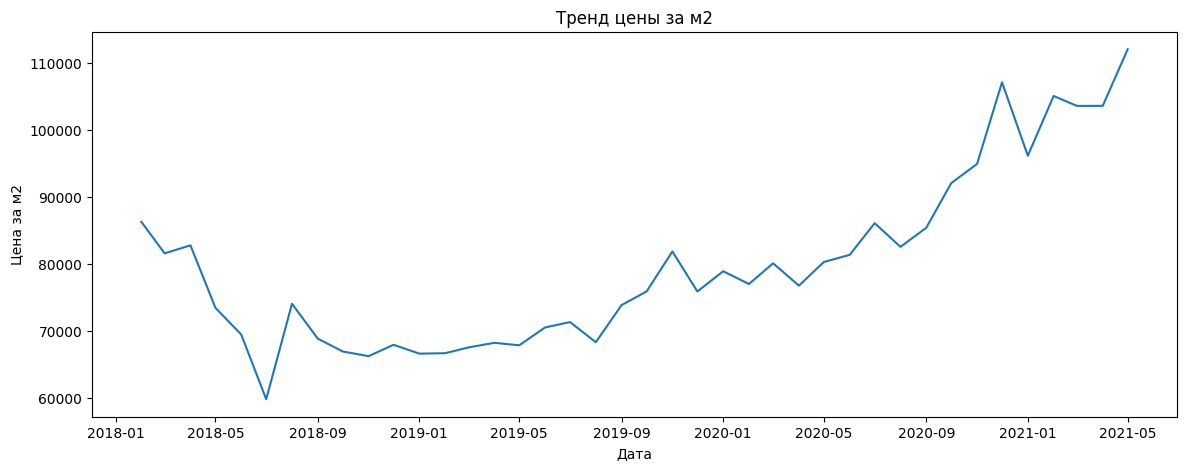

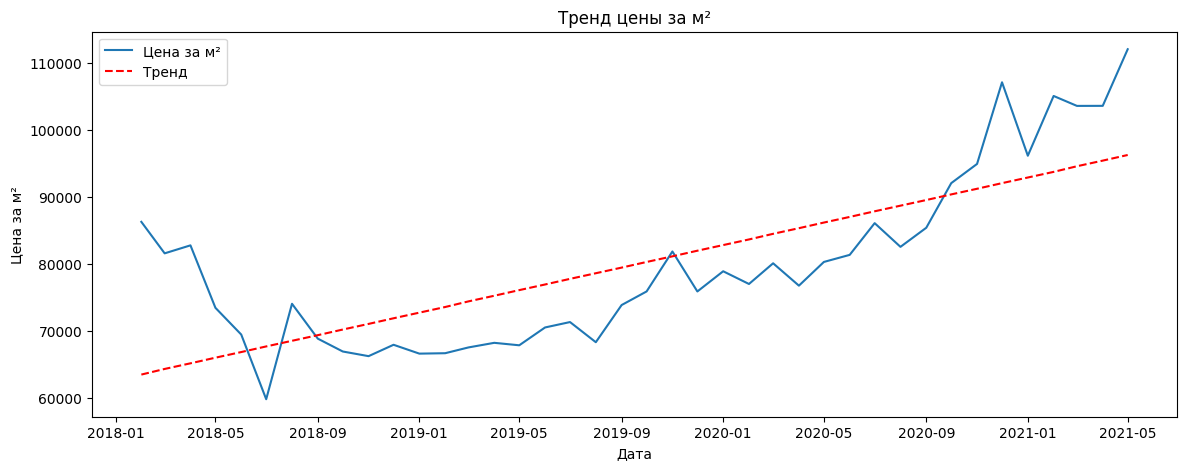

In [61]:
x = np.arange(len(price_trend)).reshape(-1, 1)
y = price_trend.values

model = LinearRegression()
model.fit(x, y)
trend_line = model.predict(x)

plt.figure(figsize=(14, 5))
plt.plot(price_trend.index, y, label='Цена за м²')
plt.plot(price_trend.index, trend_line, color='red', linestyle='--', label='Тренд')
plt.title('Тренд цены за м²')
plt.xlabel('Дата')
plt.ylabel('Цена за м²')
plt.legend()
plt.show()

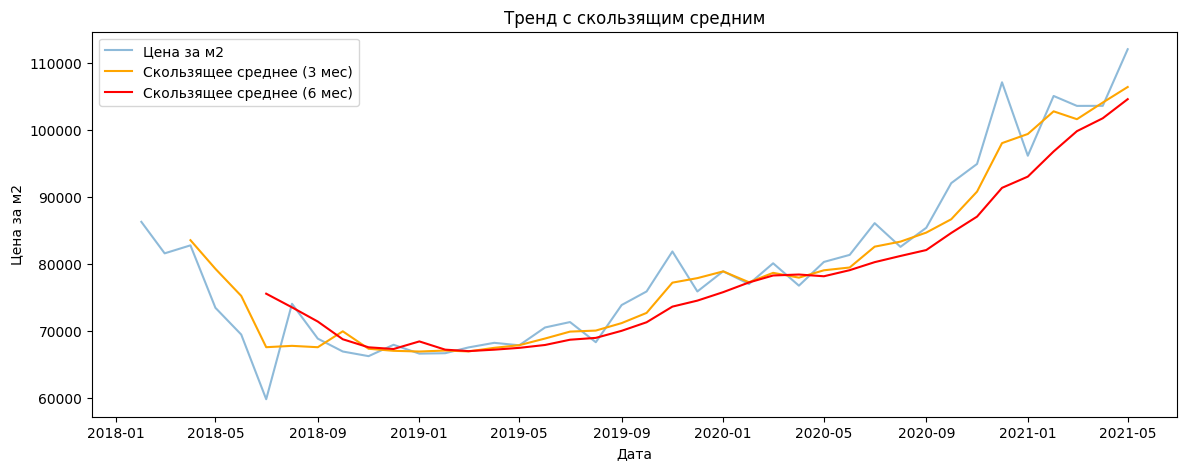

In [62]:
plt.figure(figsize=(14, 5))
plt.plot(price_trend.index, price_trend.values, alpha=0.5, label='Цена за м2')
plt.plot(price_trend.index, price_trend.rolling(3).mean(), color='orange', label='Скользящее среднее (3 мес)')
plt.plot(price_trend.index, price_trend.rolling(6).mean(), color='red', label='Скользящее среднее (6 мес)')
plt.title('Тренд с скользящим средним')
plt.xlabel('Дата')
plt.ylabel('Цена за м2')
plt.legend()
plt.show()

In [63]:
mse = mean_squared_error(price_trend.values, trend_line)
print(f"RMSE: {np.sqrt(mse):.2f}")

RMSE: 8538.38


In [64]:
mape = np.mean(np.abs((price_trend.values - trend_line) / price_trend.values)) * 100
print(f"MAPE ошибка в %: {mape:.2f}%")

MAPE ошибка в %: 8.83%


In [65]:
r2 = r2_score(price_trend.values, trend_line)
r2

0.5636043484428204

Наблюдается устойчивый восходящий тренд цен за м2 с 2018 по 2021 год. Линейная регрессия тренда даёт R2 = 0.56, MAPE = 8.83% — тренд объясняет чуть больше половины динамики, что говорит о наличии сезонности и региональных различий.

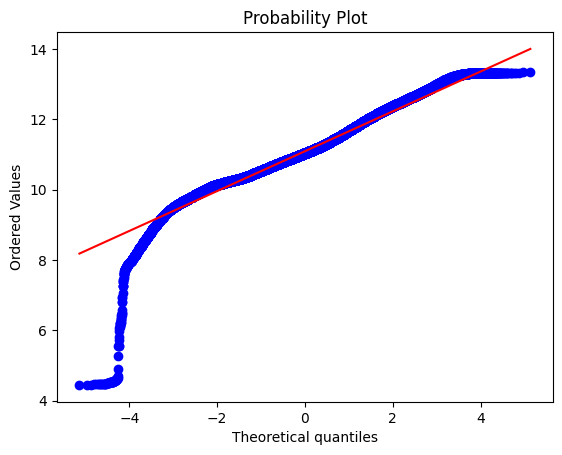

In [66]:
st.probplot(df['log_price_m2'], dist="norm", plot=plt)
plt.show()

Центральная часть (примерно от −2 до +3 по оси теоретических квантилей) — точки плотно прилегают к красной линии. Это говорит о том, что основная масса данных хорошо описывается нормальным распределением.

# 6. Когда выгодно покупать/продавать объект недвижимости? 

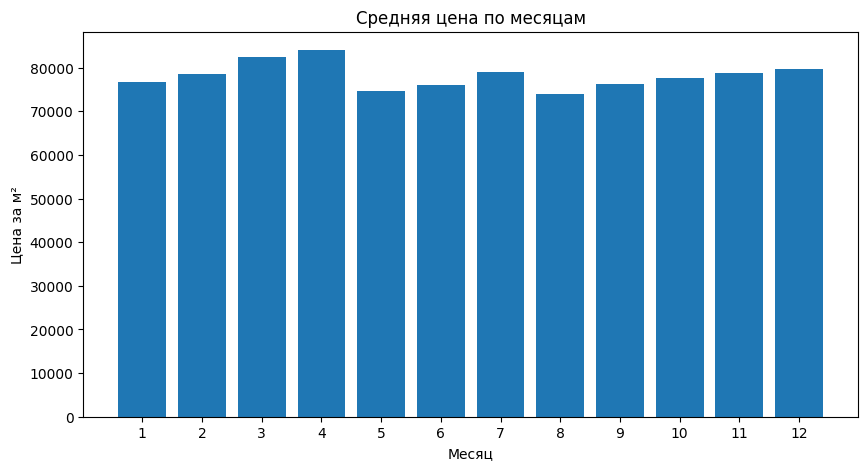

In [67]:
df['month'] = df['date'].dt.month

# Средняя цена по месяцам
monthly_price = df.groupby('month')['price_m2'].mean()

plt.figure(figsize=(10, 5))
plt.bar(monthly_price.index, monthly_price.values)
plt.xlabel('Месяц')
plt.ylabel('Цена за м²')
plt.title('Средняя цена по месяцам')
plt.xticks(range(1, 13))
plt.show()

In [68]:
monthly_price.idxmax(), monthly_price.idxmin()

(4, 8)

Цены за м2 достигают максимума в марте–апреле и минимума в августе. Таким образом, продавать выгоднее весной, покупать — в конце лета

In [69]:
key_rate = pd.read_csv('key_rate.csv')
key_rate['date'] = pd.to_datetime(key_rate['date'], format='%d.%m.%Y')
key_rate = key_rate.sort_values('date')

df = df.sort_values('date')
df = pd.merge_asof(df, key_rate, on='date', direction='backward')

In [70]:
df

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,year,code,reg_name,price_m2,log_price_m2,area_bin,month,key_rate
0,6050000,2018-02-19,2661,1,8,10,3,82.6,10.8,1,2018,2661.0,Санкт-Петербург,73244.552058,11.201573,"(80, 90]",2,7.5
1,8650000,2018-02-27,81,3,5,24,2,69.1,12.0,1,2018,81.0,Московская область,125180.897250,11.737523,"(60, 70]",2,7.5
2,4000000,2018-02-28,2871,1,5,9,3,66.0,10.0,1,2018,2871.0,Нижегородская область,60606.060606,11.012167,"(60, 70]",2,7.5
3,1850000,2018-03-01,2843,4,12,16,2,38.0,5.0,11,2018,2843.0,Краснодарский край,48684.210526,10.793131,"(30, 40]",3,7.5
4,5450000,2018-03-01,81,3,13,14,2,60.0,10.0,1,2018,81.0,Московская область,90833.333333,11.416793,"(50, 60]",3,7.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4886344,12000000,2021-05-01,2843,0,9,15,4,145.0,15.0,1,2021,2843.0,Краснодарский край,82758.620690,11.323696,"(140, 150]",5,5.0
4886345,1600000,2021-05-01,2843,3,6,6,2,42.0,9.0,1,2021,2843.0,Краснодарский край,38095.238095,10.547871,"(40, 50]",5,5.0
4886346,4250000,2021-05-01,2843,4,9,9,3,58.6,7.5,1,2021,2843.0,Краснодарский край,72525.597270,11.191709,"(50, 60]",5,5.0
4886347,3100000,2021-05-01,2843,4,5,5,2,48.0,6.0,1,2021,2843.0,Краснодарский край,64583.333333,11.075727,"(40, 50]",5,5.0


In [71]:
df[['key_rate', 'price_m2']].corr()

,key_rate,price_m2
key_rate,1.000000,-0.200473
price_m2,-0.200473,1.000000


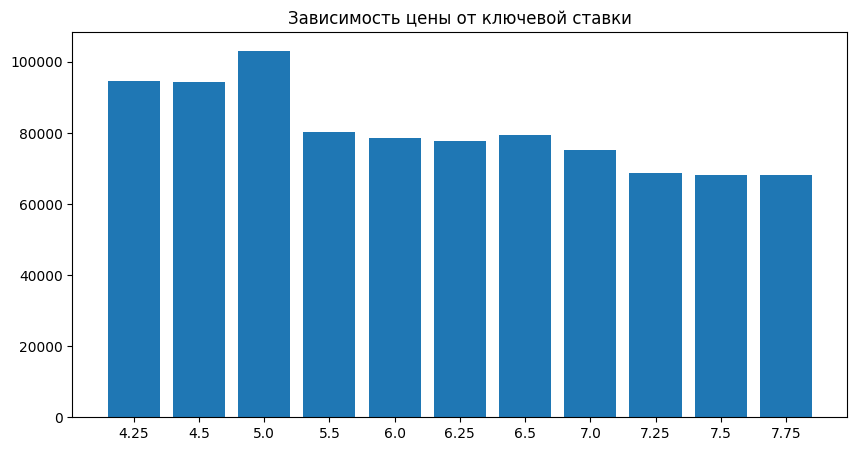

In [72]:
price_by_rate = df.groupby('key_rate')['price_m2'].mean()
plt.figure(figsize=(10, 5))
plt.bar(price_by_rate.index.astype(str), price_by_rate.values)
plt.title('Зависимость цены от ключевой ставки')
plt.show()

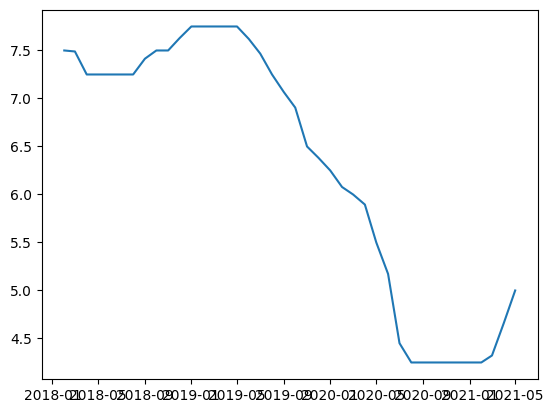

In [73]:
a = df.groupby(df['date'].dt.to_period('M'))['key_rate'].mean()
a.index = a.index.to_timestamp()
plt.plot(a.index, a.values)
plt.show()

Корреляция между ключевой ставкой и ценой за м2 составляет −0.20 — связь статистически фиксируется, но остаётся слабой: ставка объясняет лишь около 4%. Общая логика: снижение ставки удешевляет ипотеку, стимулирует спрос, цена растет, рост ставки его охлаждает. 

In [74]:
df

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type,year,code,reg_name,price_m2,log_price_m2,area_bin,month,key_rate
0,6050000,2018-02-19,2661,1,8,10,3,82.6,10.8,1,2018,2661.0,Санкт-Петербург,73244.552058,11.201573,"(80, 90]",2,7.5
1,8650000,2018-02-27,81,3,5,24,2,69.1,12.0,1,2018,81.0,Московская область,125180.897250,11.737523,"(60, 70]",2,7.5
2,4000000,2018-02-28,2871,1,5,9,3,66.0,10.0,1,2018,2871.0,Нижегородская область,60606.060606,11.012167,"(60, 70]",2,7.5
3,1850000,2018-03-01,2843,4,12,16,2,38.0,5.0,11,2018,2843.0,Краснодарский край,48684.210526,10.793131,"(30, 40]",3,7.5
4,5450000,2018-03-01,81,3,13,14,2,60.0,10.0,1,2018,81.0,Московская область,90833.333333,11.416793,"(50, 60]",3,7.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4886344,12000000,2021-05-01,2843,0,9,15,4,145.0,15.0,1,2021,2843.0,Краснодарский край,82758.620690,11.323696,"(140, 150]",5,5.0
4886345,1600000,2021-05-01,2843,3,6,6,2,42.0,9.0,1,2021,2843.0,Краснодарский край,38095.238095,10.547871,"(40, 50]",5,5.0
4886346,4250000,2021-05-01,2843,4,9,9,3,58.6,7.5,1,2021,2843.0,Краснодарский край,72525.597270,11.191709,"(50, 60]",5,5.0
4886347,3100000,2021-05-01,2843,4,5,5,2,48.0,6.0,1,2021,2843.0,Краснодарский край,64583.333333,11.075727,"(40, 50]",5,5.0


# 7. Определите от каких признаков зависит стоимость объекта недвижимости. Найдите скрытые закономерности.

In [75]:
%%time
features = ['area', 'kitchen_area', 'rooms', 'level', 'levels', 'building_type', 'object_type', 'key_rate']
X = df[features].dropna()
y = df.loc[X.index, 'price_m2']

model = RandomForestRegressor(n_estimators=1)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

CPU times: user 19 s, sys: 419 ms, total: 19.4 s
Wall time: 19.3 s


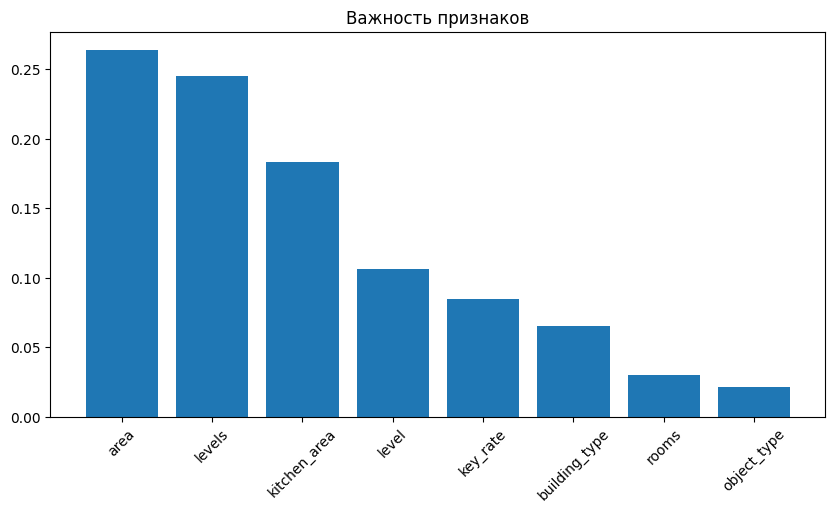

In [76]:
plt.figure(figsize=(10, 5))
plt.bar(importance.index, importance.values)
plt.title('Важность признаков')
plt.xticks(rotation=45)
plt.show()

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

features = ['area', 'kitchen_area', 'rooms', 'level', 'levels', 
            'building_type', 'object_type', 'region', 'key_rate']

X = df[features].copy()
y = df['price_m2']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# категориальные признаки
cat_features = ['building_type', 'object_type', 'region']

model = CatBoostRegressor(
    iterations=100,
    task_type='GPU',
    cat_features=cat_features,
    verbose=10
)
model.fit(X_train, y_train)

Learning rate set to 0.471926
0:	learn: 40503.1474140	total: 22.4ms	remaining: 2.22s
10:	learn: 26342.6101002	total: 220ms	remaining: 1.78s
20:	learn: 25659.8980575	total: 414ms	remaining: 1.56s
30:	learn: 25362.6626216	total: 610ms	remaining: 1.36s
40:	learn: 25128.8388265	total: 800ms	remaining: 1.15s
50:	learn: 24977.0719248	total: 984ms	remaining: 945ms
60:	learn: 24823.5832763	total: 1.17s	remaining: 748ms
70:	learn: 24707.9268775	total: 1.36s	remaining: 555ms
80:	learn: 24636.5524522	total: 1.54s	remaining: 362ms
90:	learn: 24563.6931003	total: 1.73s	remaining: 171ms
99:	learn: 24489.7491648	total: 1.9s	remaining: 0us


In [80]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"RMSE: {rmse:,.0f}")
print(f"MAE: {mae:,.0f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 24,514
MAE: 15,302
R²: 0.8010
MAPE: 22.81%


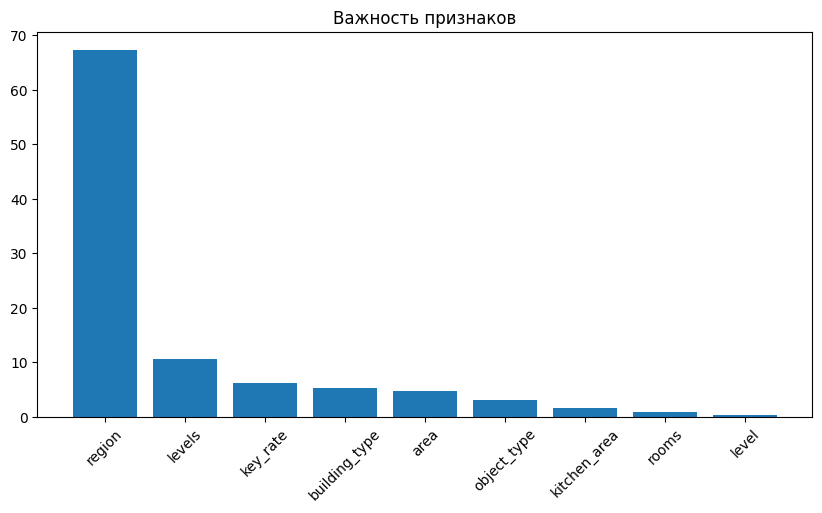

In [81]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(importance.index, importance.values)
plt.title('Важность признаков')
plt.xticks(rotation=45)
plt.show()

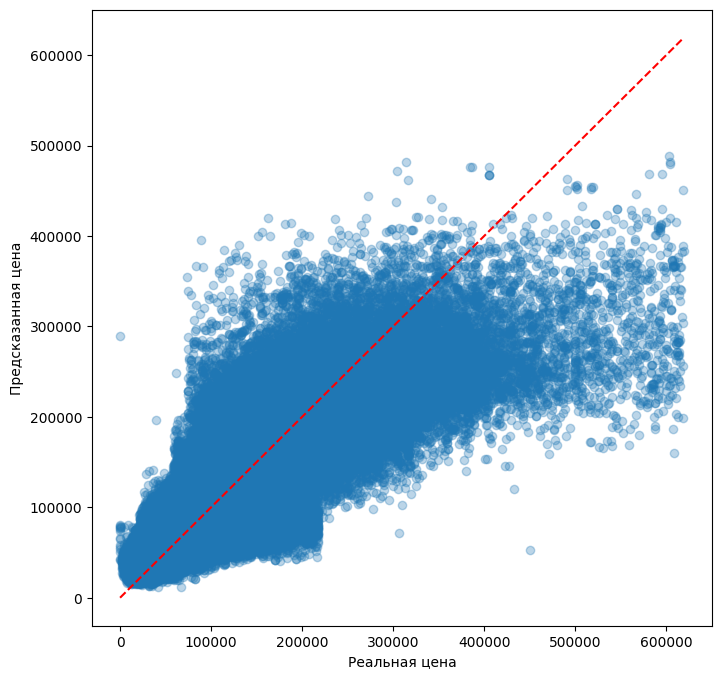

In [82]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.show()

In [83]:
X_train

,area,kitchen_area,rooms,level,levels,building_type,object_type,region,key_rate
972655,32.00,6.00,1,3,5,3,1,81,7.75
4241555,25.32,5.00,1,16,17,2,11,2843,4.25
521202,47.33,14.45,1,5,25,0,11,9654,7.50
4851587,43.00,9.00,1,3,10,1,1,9654,5.00
99779,58.00,12.00,2,12,14,1,1,3,7.50
...,...,...,...,...,...,...,...,...,...
1136074,38.30,18.10,1,2,14,2,11,3,7.75
1570006,54.00,8.00,3,1,2,1,1,5241,7.75
2234489,48.00,28.00,2,7,9,3,1,3230,7.00
4304572,33.00,6.00,1,1,5,1,1,2871,4.25


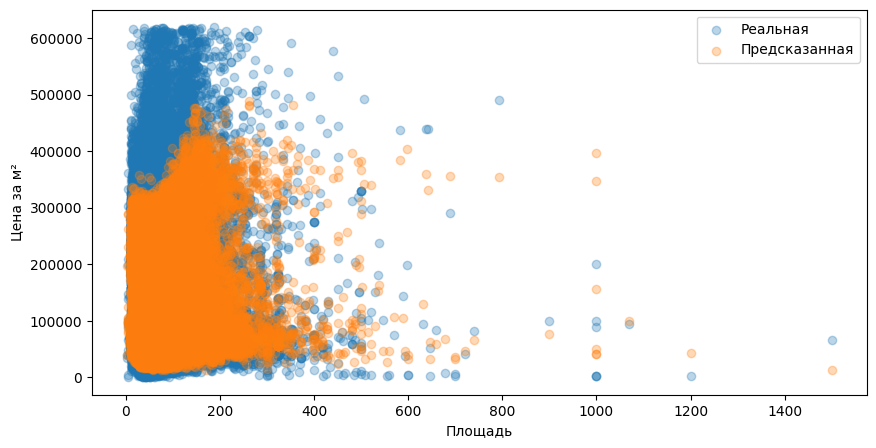

In [84]:
plt.figure(figsize=(10, 5))
plt.scatter(X_test['area'], y_test, alpha=0.3, label='Реальная')
plt.scatter(X_test['area'], y_pred, alpha=0.3, label='Предсказанная')
plt.xlabel('Площадь')
plt.ylabel('Цена за м²')
plt.legend()
plt.show()

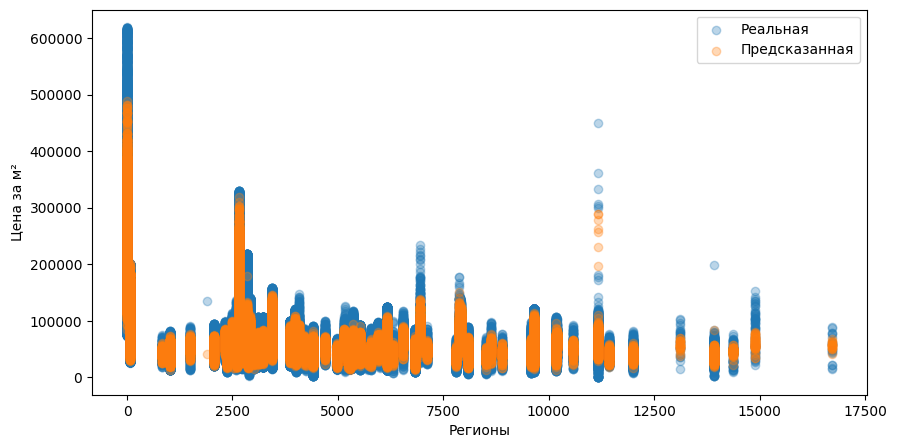

In [85]:
plt.figure(figsize=(10, 5))
plt.scatter(X_test['region'], y_test, alpha=0.3, label='Реальная')
plt.scatter(X_test['region'], y_pred, alpha=0.3, label='Предсказанная')
plt.xlabel('Регионы')
plt.ylabel('Цена за м²')
plt.legend()
plt.show()

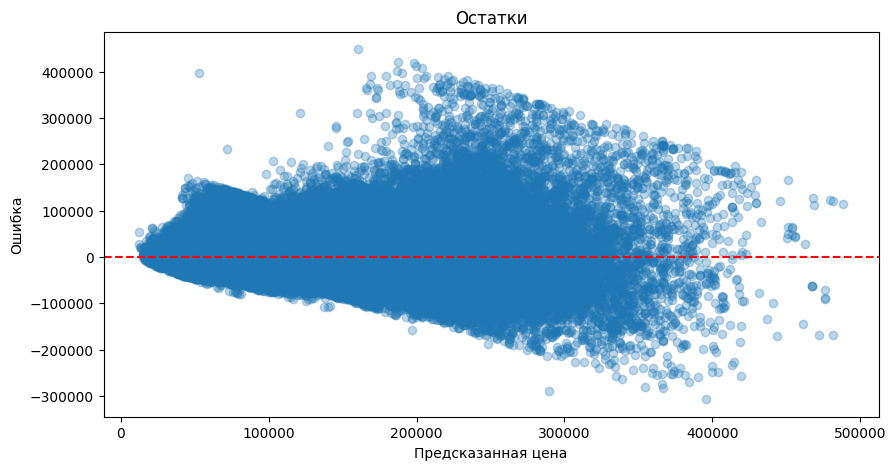

In [86]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанная цена')
plt.ylabel('Ошибка')
plt.title('Остатки')
plt.show()

Модель показала R2 = 0.80 — то есть объясняет 80% разброса цен. Средняя ошибка (MAE) — 15 302 руб/м2, MAPE — 22.81%. </br></br>
Самый важный признак — регион (67%), остальные сильно отстают: этажность (10%), ключевая ставка (6%), тип здания и площадь (5%). Число комнат и этаж квартиры почти не влияют. </br></br>
Модель хорошо предсказывает цены до 200 000 руб/м2 — точки лежат близко к диагонали. Выше 300 000 модель стабильно занижает, потому что таких объектов мало в данных.</br></br>
По площади: до 200 м2 предсказания хорошо совпадают с реальными, а на больших площадях модель не ловит разброс.</br></br>
Остатки расходятся веером — чем дороже объект, тем больше ошибка. Это значит, что модель работает надёжно в массовом сегменте, а для дорогого жилья нужна доработка.